In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [17]:
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
print("dt = ", dt)
tau_sfh_def = 6 #Gyrs
tau_sfh_2 = 15 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh_def)
m_g_array_const = np.ones(len(t_array))

gal_def_2024 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp)

tau_star = gal_def_2024.tau_star_arr[0]
eta = gal_def_2024.eta_arr[0]
print("tau_* = ", tau_star)
print("eta = ", eta)

mdot_star_const = m_g_array_const/tau_star
mdot_star_exp = m_g_array_exp/tau_star

mstars_const = mdot_star_const * dt
cdf_mstars_const = np.cumsum(mstars_const)/np.sum(mstars_const)

mstars_exp = mdot_star_exp * dt
cdf_mstars_exp = np.cumsum(mstars_exp)/np.sum(mstars_exp)

dt =  0.014013913913913914
tau_* =  1.0
eta =  2.5


Text(0, 0.5, 'Cumulative mass of stars made at times t')

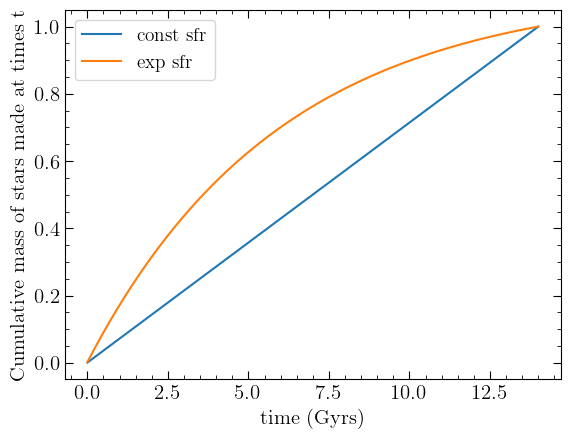

In [18]:
plt.plot(t_array, cdf_mstars_const, label = 'const sfr')
plt.plot(t_array, cdf_mstars_exp, label = 'exp sfr')

plt.legend()
plt.xlabel('time (Gyrs)')
plt.ylabel('Cumulative mass of stars made at times t')

Text(0, 0.5, 'Mass of stars being formed at t (M_sun)')

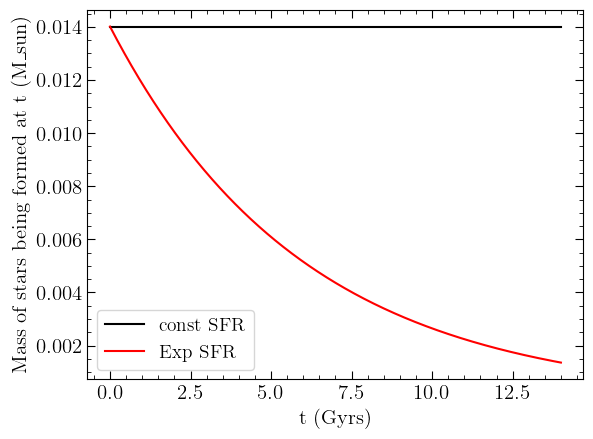

In [19]:
plt.plot(t_array, mstars_const, color = 'black', label = 'const SFR')
plt.plot(t_array, mstars_exp, color = 'red', label = 'Exp SFR')

plt.legend()
plt.xlabel('t (Gyrs)')
plt.ylabel('Mass of stars being formed at t (M_sun)')

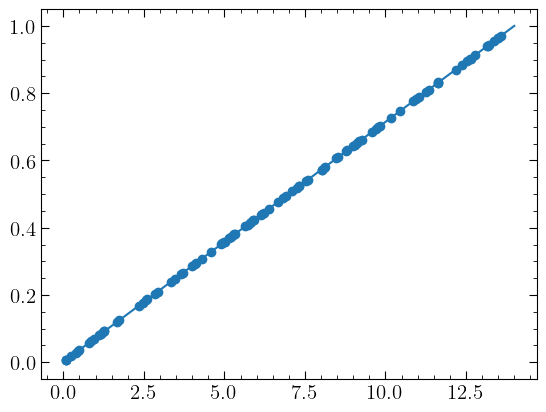

In [26]:
# 2. Define how many samples you want
n_samples = 100
# 3. Generate uniform random numbers
u = np.random.rand(n_samples)
# 4. Perform the inverse sampling to get indices
sampled_indices = np.searchsorted(cdf_mstars_const, u)

plt.scatter(t_array[sampled_indices], cdf_mstars_const[sampled_indices])
plt.plot(t_array, cdf_mstars_const, label = 'const sfr')

In [37]:
star_groups_times = t_array[sampled_indices]
star_group_masses = mstars_const[sampled_indices]

error_on_met = 0.05
gal_1_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O'])

for i in range(len(sampled_indices)):
    gal_1_df['O_H'] = np.random.normal(loc=gal_def_2024.O_H[sampled_indices[i]], scale = error_on_met, size=len(sampled_indices))
    gal_1_df['Fe_O'] = np.random.normal(loc=gal_def_2024.Fe_O[sampled_indices[i]], scale = error_on_met, size=len(sampled_indices))
    gal_1_df['Mn_O'] = np.random.normal(loc=gal_def_2024.Mn_O[sampled_indices[i]], scale = error_on_met, size=len(sampled_indices))

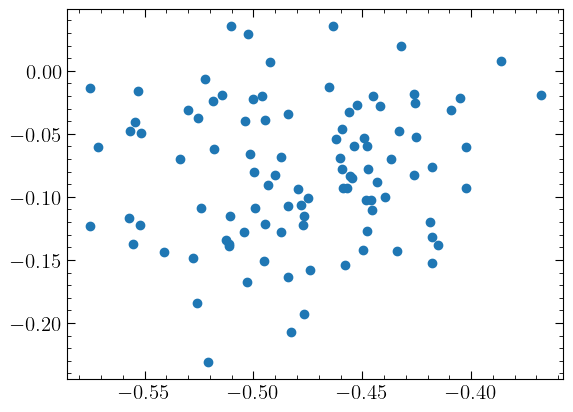

In [39]:
plt.scatter(gal_1_df['O_H'], gal_1_df['Fe_O'])

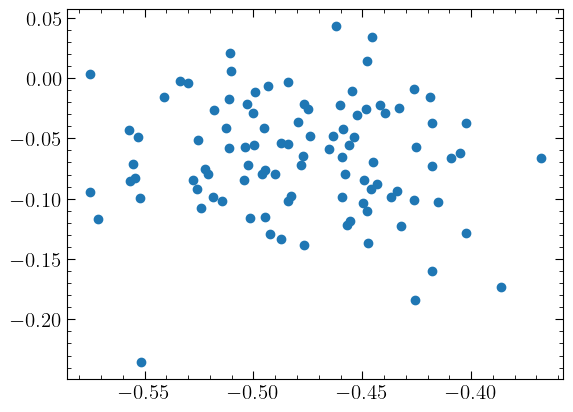

In [40]:
plt.scatter(gal_1_df['O_H'], gal_1_df['Mn_O'])

(-0.6, 0.2)

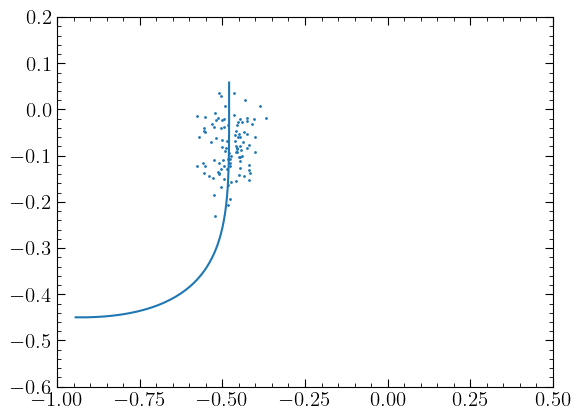

In [43]:
plt.plot(gal_def_2024.O_H[10:], gal_def_2024.Fe_O[10:])
plt.scatter(gal_1_df['O_H'], gal_1_df['Fe_O'], s = 1)

plt.xlim(-1, 0.5)
plt.ylim(-0.6, 0.2)
#plt.scatter(gal_def_2024.O_H[sampled_indices], gal_def_2024.Fe_O[sampled_indices])

In [44]:
highalpha = pd.read_csv("../highalpha.csv")
lowalpha = pd.read_csv("../lowalpha.csv")

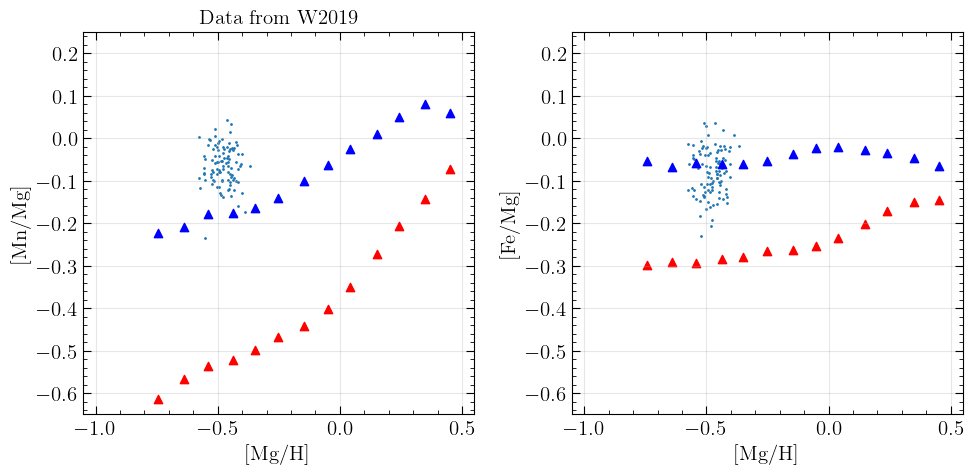

In [45]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
plt.scatter(gal_1_df['O_H'], gal_1_df['Mn_O'], s = 1)
#plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.1, color = 'gray')
#plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
#plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
#plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan')
#plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink')
#plt.plot(gal_def_2024.O_H[10:], gal_def_2024.Fe_O[10:])
plt.scatter(gal_1_df['O_H'], gal_1_df['Fe_O'], s = 1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')
plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()